In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Policy identity, synchronization and the rollout bottleneck

Day 25 · Chapter 14 · CPU worked notebook

Read Chapter14 sections14.6–14.8. Predict: after updating to version3, is a version2 response now a version3 response? Can a faster backward pass dominate the total speedup?

Saved reference preview from the bounded CPU reference execution. It is a fixed result; run the cells to regenerate figures after changing controls. Make the prediction above before inspecting the preview.

![Saved reference 1: rollout versions and budget](../figures/chapter-14/day-25-01_rollout_versions_and_budget-01.png)

In [2]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dongxi_llms").is_dir())
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (8, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
# CPU only. Local original fixtures; no checkpoint/network/server needed.


Expected freshness failure: Behavior policy version is outside the allowed lag


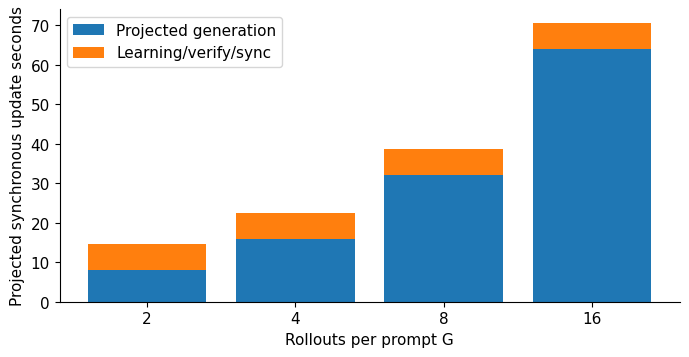

In [3]:
from dongxi_llms.optimization_diagnostics_lab import RolloutIdentity, accept_rollout, pipeline_budget
row = RolloutIdentity("original-addition-01", 2, "token-v1", "verifier-v1", "group01", 8)
assert accept_rollout(row, 2, "token-v1", "verifier-v1")
try:
    accept_rollout(row, 3, "token-v1", "verifier-v1")
except ValueError as error:
    print("Expected freshness failure:", error)
groups = [2, 4, 8, 16]
budgets = [pipeline_budget(group=g) for g in groups]
fig, ax = plt.subplots()
ax.bar([str(g) for g in groups], [r["projected_generation_seconds"] for r in budgets],
       label="Projected generation")
ax.bar([str(g) for g in groups],
       [r["projected_update_seconds"]-r["projected_generation_seconds"] for r in budgets],
       bottom=[r["projected_generation_seconds"] for r in budgets], label="Learning/verify/sync")
ax.set(xlabel="Rollouts per prompt G", ylabel="Projected synchronous update seconds")
ax.legend()
plt.show()

Reading guide: throughput128 tokens/s is an illustrative control, not a Spark measurement. The same6-second learner becomes a smaller fraction as rollout work grows.

Exercise: intentionally allow lag1, reject a tokenizer mismatch, then compare doubled generation rate with halved learner time.

In [4]:
# Reference solution: intentional lag contract still preserves behavior version2.
assert accept_rollout(row, 3, "token-v1", "verifier-v1", max_lag=1)
try:
    accept_rollout(row, 2, "token-v2", "verifier-v1")
except ValueError as error:
    print("Expected identity failure:", error)
baseline = pipeline_budget()
faster_generation = pipeline_budget(rollout_tps=256.)
faster_learning = pipeline_budget(learner_seconds=3.)
for name, value in (("baseline", baseline), ("double-generation", faster_generation),
                    ("half-learning-time", faster_learning)):
    print(name, value)
print("Passing metadata checks does not verify the sampling engine's actual weights/log probabilities.")

Expected identity failure: Token/reward identity changed
baseline {'projected_tokens': 4096, 'projected_generation_seconds': 32.0, 'projected_update_seconds': 38.6, 'projected_useful_tps': 106.11398963730569, 'projected_generation_fraction': 0.8290155440414507}
double-generation {'projected_tokens': 4096, 'projected_generation_seconds': 16.0, 'projected_update_seconds': 22.6, 'projected_useful_tps': 181.23893805309734, 'projected_generation_fraction': 0.7079646017699115}
half-learning-time {'projected_tokens': 4096, 'projected_generation_seconds': 32.0, 'projected_update_seconds': 35.6, 'projected_useful_tps': 115.0561797752809, 'projected_generation_fraction': 0.898876404494382}
Passing metadata checks does not verify the sampling engine's actual weights/log probabilities.


Controlled change: length128→256 and examine cost. Before engine integration, specify IDs, sampling distribution, tokenizer/template, verifier, version lag and EOS equivalence checks. Evidence boundary: the budget is projected and the version checker is structural, not a production vLLM validation.